# Waste Classification with CNN - Machine Learning HW2

**Davide De Blasio - 2082600**

**December 2025**

This project performs comprehensive image classification, preprocessing, dimensionality reduction, and convolutional neural network modeling on the [RealWaste Dataset (Kaggle)](https://www.kaggle.com/datasets/joebeachcapital/realwaste)

**Target Variable:** Waste Category - Multi-class Classification Task

**Approach:** We train Convolutional Neural Networks (CNN) on three versions of the dataset:
1. Original images (full resolution features)
2. PCA-reduced features  
3. Autoencoder-reduced features

We compare performance, training time, and computational efficiency across all three approaches.

## 1. Environment Setup

In [2]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np
import os
import shutil
import random
from math import floor
from collections import Counter

# Image processing
from PIL import Image

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# PyTorch and torchvision
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Sklearn for preprocessing and dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_fscore_support
)

# Progress bars and time tracking
from tqdm import tqdm
import time

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Device detection with MPS support for Apple Silicon
if torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(42)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(42)
else:
    device = torch.device("cpu")

print("Libraries imported successfully!")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Libraries imported successfully!
Device: cuda
PyTorch version: 2.9.0+cu126


## 2. Data Acquisition

In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("joebeachcapital/realwaste")

# Navigate to dataset directory
dataset_root = os.path.join(path, "realwaste-main", "RealWaste")

print(f"Dataset path: {dataset_root}")
print("Dataset downloaded successfully!")

# List all waste categories (subdirectories)
categories = sorted([d for d in os.listdir(dataset_root) 
                     if os.path.isdir(os.path.join(dataset_root, d))])

print(f"\nNumber of waste categories: {len(categories)}")
print(f"\nWaste categories:")
for i, cat in enumerate(categories, 1):
    cat_path = os.path.join(dataset_root, cat)
    num_images = len([f for f in os.listdir(cat_path) if f.endswith('.jpg')])
    print(f"  {i}. {cat}: {num_images} images")

100%|██████████| 657M/657M [00:08<00:00, 80.8MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/joebeachcapital/realwaste/versions/1/realwaste-main/RealWaste
Dataset downloaded successfully!

Number of waste categories: 9

Waste categories:
  1. Cardboard: 461 images
  2. Food Organics: 411 images
  3. Glass: 420 images
  4. Metal: 790 images
  5. Miscellaneous Trash: 495 images
  6. Paper: 500 images
  7. Plastic: 921 images
  8. Textile Trash: 318 images
  9. Vegetation: 436 images


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Statistics

In [4]:
# Count images per category
class_counts = {}
total_images = 0

for cat in categories:
    cat_path = os.path.join(dataset_root, cat)
    images = [f for f in os.listdir(cat_path) if f.endswith('.jpg')]
    class_counts[cat] = len(images)
    total_images += len(images)

print(f"Total number of images: {total_images}")
print(f"\nClass distribution:")
for cat, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_images) * 100
    print(f"  {cat}: {count} images ({percentage:.2f}%)")

# Check for class imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1 (max/min)")
if imbalance_ratio > 2.0:
    print("Significant class imbalance detected")
else:
    print("Dataset is relatively balanced")

Total number of images: 4752

Class distribution:
  Plastic: 921 images (19.38%)
  Metal: 790 images (16.62%)
  Paper: 500 images (10.52%)
  Miscellaneous Trash: 495 images (10.42%)
  Cardboard: 461 images (9.70%)
  Vegetation: 436 images (9.18%)
  Glass: 420 images (8.84%)
  Food Organics: 411 images (8.65%)
  Textile Trash: 318 images (6.69%)

Class imbalance ratio: 2.90:1 (max/min)
Significant class imbalance detected


### 3.2 Visualize Class Distribution

In [ ]:
# Plot class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
categories_sorted = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
cats, counts = zip(*categories_sorted)
colors = sns.color_palette('viridis', len(cats))

ax1.barh(cats, counts, color=colors, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Images', fontsize=12)
ax1.set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, count in enumerate(counts):
    ax1.text(count + 10, i, str(count), va='center', fontsize=10)

# Pie chart
ax2.pie(counts, labels=cats, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 Sample Images from Each Category

In [ ]:
# Display sample images from each category
n_samples = 5
n_categories = len(categories)

fig, axes = plt.subplots(n_categories, n_samples, figsize=(15, 3 * n_categories))
fig.suptitle('Sample Images from Each Waste Category', fontsize=16, fontweight='bold', y=0.995)

for i, cat in enumerate(categories):
    cat_path = os.path.join(dataset_root, cat)
    images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(images, min(n_samples, len(images)))
    
    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(cat_path, img_name)
        img = Image.open(img_path).convert('RGB')
        
        if n_categories == 1:
            ax = axes[j]
        else:
            ax = axes[i, j]
        
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(f"{cat}\n({class_counts[cat]} images)", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Image Properties Analysis

In [ ]:
# Analyze image properties
image_properties = {
    'widths': [],
    'heights': [],
    'aspect_ratios': [],
    'file_sizes_kb': []
}

# Sample a subset of images for efficiency
sample_size = min(500, total_images)
print(f"Analyzing {sample_size} random images...\n")

sampled_images = []
for cat in categories:
    cat_path = os.path.join(dataset_root, cat)
    images = [os.path.join(cat_path, f) for f in os.listdir(cat_path) if f.endswith('.jpg')]
    sampled_images.extend(random.sample(images, min(sample_size // len(categories), len(images))))

for img_path in tqdm(sampled_images, desc="Analyzing images"):
    try:
        img = Image.open(img_path)
        width, height = img.size
        image_properties['widths'].append(width)
        image_properties['heights'].append(height)
        image_properties['aspect_ratios'].append(width / height)
        image_properties['file_sizes_kb'].append(os.path.getsize(img_path) / 1024)
    except Exception as e:
        continue

# Print statistics
print(f"\nImage dimensions:")
print(f"  Width:  min={min(image_properties['widths'])}, max={max(image_properties['widths'])}, "
      f"mean={np.mean(image_properties['widths']):.1f}")
print(f"  Height: min={min(image_properties['heights'])}, max={max(image_properties['heights'])}, "
      f"mean={np.mean(image_properties['heights']):.1f}")
print(f"\nAspect ratio: min={min(image_properties['aspect_ratios']):.2f}, "
      f"max={max(image_properties['aspect_ratios']):.2f}, mean={np.mean(image_properties['aspect_ratios']):.2f}")
print(f"\nFile size (KB): min={min(image_properties['file_sizes_kb']):.1f}, "
      f"max={max(image_properties['file_sizes_kb']):.1f}, mean={np.mean(image_properties['file_sizes_kb']):.1f}")

## 4. Data Preprocessing

### 4.1 Configuration

In [49]:
# Configuration parameters
IMG_SIZE = 128  # Resize all images to 128x128 for consistency
BATCH_SIZE = 128  # Larger batch size for better gradient estimates
NUM_WORKERS = 0 if device.type == 'mps' else 4  # MPS doesn't support multiprocessing well
TARGET_DIM = 256  # Target dimensionality for PCA and Autoencoder (keeping most variance from 512D features)

print(f"Configuration:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Target dimensionality (PCA/AE): {TARGET_DIM}")
print(f"  Device: {device}")
print(f"  Number of classes: {len(categories)}")

Configuration:
  Image size: 128x128
  Batch size: 128
  Target dimensionality (PCA/AE): 256
  Device: cuda
  Number of classes: 9


### 4.2 Train/Validation/Test Split

In [6]:
# Create directories for split datasets
base_dir = './waste_split'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Remove existing split directories if they exist
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Create output directories
for split_dir in [train_dir, val_dir, test_dir]:
    os.makedirs(split_dir, exist_ok=True)

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

print("Splitting dataset into train/val/test sets...\n")

# Loop through each class folder
split_summary = {}
for class_name in categories:
    class_path = os.path.join(dataset_root, class_name)
    
    # Create class subfolders inside each split
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
    
    # Get all image files
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    random.shuffle(images)
    
    total = len(images)
    train_end = floor(total * train_ratio)
    val_end = floor(total * (train_ratio + val_ratio))
    
    # Split lists
    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]
    
    # Copy files to respective folders
    for file_list, dest_dir in [
        (train_files, os.path.join(train_dir, class_name)),
        (val_files, os.path.join(val_dir, class_name)),
        (test_files, os.path.join(test_dir, class_name))
    ]:
        for filename in file_list:
            src = os.path.join(class_path, filename)
            dst = os.path.join(dest_dir, filename)
            shutil.copy2(src, dst)
    
    split_summary[class_name] = {'train': len(train_files), 'val': len(val_files), 'test': len(test_files)}
    print(f"{class_name:20s} - Train: {len(train_files):4d}, Val: {len(val_files):4d}, Test: {len(test_files):4d}")

# Calculate overall statistics
total_train = sum(s['train'] for s in split_summary.values())
total_val = sum(s['val'] for s in split_summary.values())
total_test = sum(s['test'] for s in split_summary.values())
grand_total = total_train + total_val + total_test

print(f"\nTotal - Train: {total_train} ({total_train/grand_total*100:.1f}%), "
      f"Val: {total_val} ({total_val/grand_total*100:.1f}%), "
      f"Test: {total_test} ({total_test/grand_total*100:.1f}%)")
print("Dataset successfully split!")

Splitting dataset into train/val/test sets...

Cardboard            - Train:  322, Val:   69, Test:   70
Food Organics        - Train:  287, Val:   62, Test:   62
Glass                - Train:  294, Val:   63, Test:   63
Metal                - Train:  553, Val:  118, Test:  119
Miscellaneous Trash  - Train:  346, Val:   74, Test:   75
Paper                - Train:  350, Val:   75, Test:   75
Plastic              - Train:  644, Val:  138, Test:  139
Textile Trash        - Train:  222, Val:   48, Test:   48
Vegetation           - Train:  305, Val:   65, Test:   66

Total - Train: 3323 (69.9%), Val: 712 (15.0%), Test: 717 (15.1%)
Dataset successfully split!


### 4.3 Data Augmentation and Transforms

In [7]:
# Data transformations with augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Data transformations without augmentation for validation and test
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Image transformations defined:")
print("\nTraining (with augmentation):")
print("  - Resize, Random horizontal flip, Random rotation (±15°)")
print("  - Color jitter, Random affine, Normalization (ImageNet stats)")
print("\nValidation/Test (no augmentation):")
print("  - Resize, Normalization (ImageNet stats)")

Image transformations defined:

Training (with augmentation):
  - Resize, Random horizontal flip, Random rotation (±15°)
  - Color jitter, Random affine, Normalization (ImageNet stats)

Validation/Test (no augmentation):
  - Resize, Normalization (ImageNet stats)


### 4.4 Visualize Augmentation Effects

In [ ]:
# Show original image and augmented versions
sample_class = categories[0]
sample_img_path = os.path.join(dataset_root, sample_class, 
                               os.listdir(os.path.join(dataset_root, sample_class))[0])

# Load original image
original_img = Image.open(sample_img_path)

# Create figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Augmentation Effects - {sample_class}', fontsize=16, fontweight='bold')

# Show original image (larger in first row)
axes[0, 0].imshow(original_img)
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Hide remaining plots in first row
for i in range(1, 4):
    axes[0, i].axis('off')

# Apply individual augmentations for visualization
augmentation_transforms = {
    'Horizontal Flip': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
    ]),
    'Rotation (15°)': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
    ]),
    'Color Jitter': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
    ]),
    'Random Affine': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
    ]),
}

# Apply and display each augmentation
for idx, (aug_name, transform) in enumerate(augmentation_transforms.items()):
    # Set seed for reproducibility of random augmentation
    torch.manual_seed(42 + idx)
    random.seed(42 + idx)
    
    # Apply transformation
    augmented = transform(original_img)
    
    # Convert tensor to numpy for display
    augmented_np = augmented.permute(1, 2, 0).numpy()
    
    axes[1, idx].imshow(augmented_np)
    axes[1, idx].set_title(aug_name, fontsize=10)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Sample image from: {sample_class}")
print(f"Original size: {original_img.size}")
print(f"After resize: {IMG_SIZE}x{IMG_SIZE}")

### 4.5 Create PyTorch Datasets and DataLoaders

In [8]:
# Create datasets
train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = ImageFolder(test_dir, transform=val_test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Get class names and create index mapping
class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_names)

print(f"Datasets and DataLoaders created successfully!")
print(f"\nDataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Datasets and DataLoaders created successfully!

Dataset sizes: Train: 3323, Val: 712, Test: 717
Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


## 5. Feature Extraction for Dimensionality Reduction

### 5.1 Extract Flattened Features

In [50]:
def extract_features(dataloader):
    """Extract and flatten features from a dataloader."""
    features_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            # Flatten images: (batch_size, channels, height, width) -> (batch_size, channels*height*width)
            flattened = images.view(images.size(0), -1)
            features_list.append(flattened.cpu())
            labels_list.append(labels.cpu())
    
    features = torch.cat(features_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return features, labels

# Use pretrained ResNet18 as feature extractor for deep features
print("Setting up pretrained feature extractor (ResNet18)...")
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18 and remove the final classification layer
resnet_extractor = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_extractor = nn.Sequential(*list(resnet_extractor.children())[:-1])  # Remove FC layer
resnet_extractor = resnet_extractor.to(device)
resnet_extractor.eval()

def extract_deep_features(dataloader):
    """Extract deep features using pretrained ResNet18."""
    features_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting deep features"):
            images = images.to(device)
            # ResNet18 outputs (batch, 512, 1, 1) - flatten to (batch, 512)
            features = resnet_extractor(images)
            features = features.view(features.size(0), -1)
            features_list.append(features.cpu())
            labels_list.append(labels.cpu())
    
    features = torch.cat(features_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return features, labels

print("Extracting DEEP features from all datasets using ResNet18...")
print("Note: These are semantically meaningful features (512-dim per image)")

# Extract deep features
X_train_flat, y_train_flat = extract_deep_features(train_loader)
X_val_flat, y_val_flat = extract_deep_features(val_loader)
X_test_flat, y_test_flat = extract_deep_features(test_loader)

print(f"\nExtracted deep feature shapes:")
print(f"  Train: {X_train_flat.shape}, Labels: {y_train_flat.shape}")
print(f"  Val:   {X_val_flat.shape}, Labels: {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape}, Labels: {y_test_flat.shape}")

Setting up pretrained feature extractor (ResNet18)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Extracting DEEP features from all datasets using ResNet18...
Note: These are semantically meaningful features (512-dim per image)


Extracting deep features: 100%|██████████| 6/6 [00:03<00:00,  1.66it/s]


Extracted deep feature shapes:
  Train: (3323, 512), Labels: (3323,)
  Val:   (712, 512), Labels: (712,)
  Test:  (717, 512), Labels: (717,)


### 5.2 Standardize Features

In [51]:
# Standardize features (FIT on train, TRANSFORM on all)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

print("Features standardized successfully!")
print(f"\nTrain set - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Val set   - Mean: {X_val_scaled.mean():.6f}, Std: {X_val_scaled.std():.6f}")
print(f"Test set  - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

Features standardized successfully!

Train set - Mean: -0.000000, Std: 1.000000
Val set   - Mean: 0.067228, Std: 1.223616
Test set  - Mean: 0.072622, Std: 1.238887


## 6. Dimensionality Reduction

### 6.1 PCA (Principal Component Analysis)

Components for 90% variance: 178
Components for 95% variance: 254
Components for 99% variance: 405


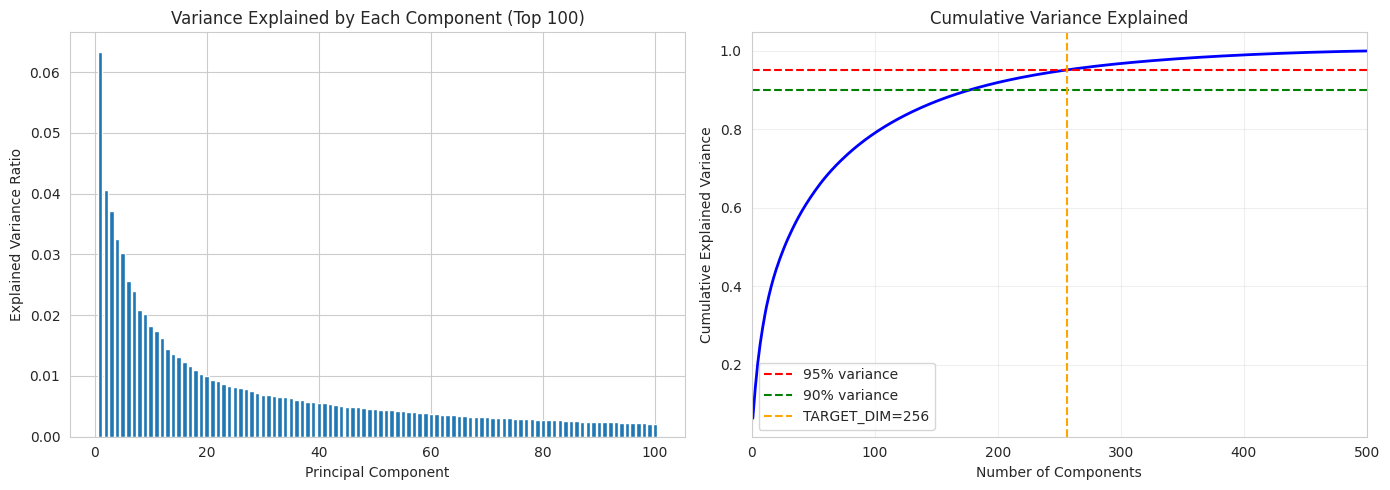


Variance explained with 256 components: 95.10%


In [52]:
# Analyze variance explained by PCA components
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
thresholds = [0.90, 0.95, 0.99]
for thresh in thresholds:
    n_comp = np.argmax(cumulative_variance >= thresh) + 1
    print(f"Components for {thresh*100:.0f}% variance: {n_comp}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance (first 100 components)
axes[0].bar(range(1, 101), pca_full.explained_variance_ratio_[:100])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained by Each Component (Top 100)')

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% variance')
axes[1].axvline(x=TARGET_DIM, color='orange', linestyle='--', label=f'TARGET_DIM={TARGET_DIM}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].set_xlim([0, 500])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Variance at TARGET_DIM
print(f"\nVariance explained with {TARGET_DIM} components: {cumulative_variance[TARGET_DIM-1]*100:.2f}%")

### 6.2 Apply PCA Transformation

In [53]:
# Apply PCA with TARGET_DIM components
pca = PCA(n_components=TARGET_DIM)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA Transformation Complete:")
print(f"  Original shape: {X_train_scaled.shape}")
print(f"  Reduced shape:  {X_train_pca.shape}")
print(f"  Compression ratio: {X_train_scaled.shape[1] / TARGET_DIM:.1f}x")
print(f"  Variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PCA Transformation Complete:
  Original shape: (3323, 512)
  Reduced shape:  (3323, 256)
  Compression ratio: 2.0x
  Variance retained: 95.04%


### 6.3 Autoencoder Architecture

In [54]:
class Autoencoder(nn.Module):
    """Autoencoder for dimensionality reduction of deep features."""
    
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: 512 -> 384 -> latent_dim (256)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 384),
            nn.BatchNorm1d(384),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(384, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )
        
        # Decoder: latent_dim (256) -> 384 -> 512
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 384),
            nn.BatchNorm1d(384),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(384, input_dim)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        reconstructed = self.decode(z)
        return reconstructed

# Create autoencoder
input_dim = X_train_scaled.shape[1]
autoencoder = Autoencoder(input_dim, TARGET_DIM).to(device)

# Count parameters
total_params = sum(p.numel() for p in autoencoder.parameters())
trainable_params = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"Autoencoder Architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Latent dimension: {TARGET_DIM}")
print(autoencoder)
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Total parameters: {total_params:,}")

Autoencoder Architecture:
  Input dimension: 512
  Latent dimension: 256
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=512, out_features=384, bias=True)
    (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=384, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=384, bias=True)
    (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=384, out_features=512, bias=True)
  )
)
  Trainable parameters: 593,408
  Total parameters: 593,408


### 6.4 Train Autoencoder

In [55]:
# Create tensor datasets for autoencoder training
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

ae_train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
ae_val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
ae_val_loader = DataLoader(ae_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Training configuration
AE_EPOCHS = 50
ae_optimizer = optim.AdamW(autoencoder.parameters(), lr=5e-4, weight_decay=1e-4)
ae_scheduler = optim.lr_scheduler.ReduceLROnPlateau(ae_optimizer, mode='min', factor=0.5, patience=7)
ae_criterion = nn.MSELoss()

# Training loop
ae_train_losses = []
ae_val_losses = []
best_ae_loss = float('inf')

print("Training Autoencoder...")

for epoch in range(AE_EPOCHS):
    # Training
    autoencoder.train()
    train_loss = 0.0
    for data, _ in ae_train_loader:
        data = data.to(device)
        ae_optimizer.zero_grad()
        reconstructed = autoencoder(data)
        loss = ae_criterion(reconstructed, data)
        loss.backward()
        ae_optimizer.step()
        train_loss += loss.item() * data.size(0)
    
    train_loss /= len(ae_train_loader.dataset)
    ae_train_losses.append(train_loss)
    
    # Validation
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, _ in ae_val_loader:
            data = data.to(device)
            reconstructed = autoencoder(data)
            loss = ae_criterion(reconstructed, data)
            val_loss += loss.item() * data.size(0)
    
    val_loss /= len(ae_val_loader.dataset)
    ae_val_losses.append(val_loss)
    
    # Scheduler step
    ae_scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_ae_loss:
        best_ae_loss = val_loss
        best_ae_state = autoencoder.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{AE_EPOCHS}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

# Load best model
autoencoder.load_state_dict(best_ae_state)
print(f"Best Validation Loss: {best_ae_loss:.6f}")

Training Autoencoder...
Epoch [10/50] - Train Loss: 0.502792, Val Loss: 0.659488
Epoch [20/50] - Train Loss: 0.406258, Val Loss: 0.539493
Epoch [30/50] - Train Loss: 0.366622, Val Loss: 0.490048
Epoch [40/50] - Train Loss: 0.344252, Val Loss: 0.465357
Epoch [50/50] - Train Loss: 0.332862, Val Loss: 0.449168
Best Validation Loss: 0.447880


### 6.5 Autoencoder Training Curves

In [ ]:
# Plot autoencoder training curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, AE_EPOCHS + 1), ae_train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(range(1, AE_EPOCHS + 1), ae_val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Encode Features with Autoencoder

In [56]:
# Encode features using trained autoencoder
autoencoder.eval()
with torch.no_grad():
    X_train_ae = autoencoder.encode(X_train_tensor.to(device)).cpu().numpy()
    X_val_ae = autoencoder.encode(X_val_tensor.to(device)).cpu().numpy()
    X_test_ae = autoencoder.encode(X_test_tensor.to(device)).cpu().numpy()

print(f"Autoencoder Encoding Complete:")
print(f"  Original shape: {X_train_scaled.shape}")
print(f"  Encoded shape:  {X_train_ae.shape}")
print(f"  Compression ratio: {X_train_scaled.shape[1] / TARGET_DIM:.1f}x")

Autoencoder Encoding Complete:
  Original shape: (3323, 512)
  Encoded shape:  (3323, 256)
  Compression ratio: 2.0x


## 7. CNN Architectures

### 7.1 Original CNN (Full Image Input)

In [16]:
class WasteCNN(nn.Module):
    """CNN for waste classification using full image input."""
    
    def __init__(self, num_classes):
        super(WasteCNN, self).__init__()
        
        # Convolutional layers
        self.features = nn.Sequential(
            # Block 1: 3 -> 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 128 -> 64
            nn.Dropout2d(0.2),
            
            # Block 2: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64 -> 32
            nn.Dropout2d(0.2),
            
            # Block 3: 64 -> 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 -> 16
            nn.Dropout2d(0.2),
            
            # Block 4: 128 -> 256 channels
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16 -> 8
            nn.Dropout2d(0.2),
        )
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# Create model
num_classes = len(class_names)
cnn_original = WasteCNN(num_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in cnn_original.parameters())
trainable_params = sum(p.numel() for p in cnn_original.parameters() if p.requires_grad)
print(f"WasteCNN (Original Image Input):")
print(f"  Input: {IMG_SIZE}x{IMG_SIZE}x3 images")
print(f"  Output: {num_classes} classes")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

WasteCNN (Original Image Input):
  Input: 128x128x3 images
  Output: 9 classes
  Total parameters: 1,242,793
  Trainable parameters: 1,242,793


### 7.2 Reduced CNN (For PCA/Autoencoder Features)

In [83]:
class ReducedCNN(nn.Module):
    """Classifier for reduced dimensionality deep features with balanced regularization."""
    
    def __init__(self, input_dim, num_classes):
        super(ReducedCNN, self).__init__()
        
        # Two hidden layers for better feature transformation
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.classifier(x)

# Create models for PCA and Autoencoder features
cnn_pca = ReducedCNN(TARGET_DIM, num_classes).to(device)
cnn_ae = ReducedCNN(TARGET_DIM, num_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in cnn_pca.parameters())

print(f"ReducedCNN (For Reduced Features):")
print(f"  Input dimension: {TARGET_DIM}")
print(f"  Output: {num_classes} classes")
print(f"  Total parameters: {total_params:,}")

ReducedCNN (For Reduced Features):
  Input dimension: 256
  Output: 9 classes
  Total parameters: 42,121


## 8. Model Training

### 8.1 Training Function

In [74]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs, model_name, is_image_model=True):
    """
    Train a model with early stopping and learning rate scheduling.
    
    Args:
        model: PyTorch model to train
        train_loader: Training data loader
        val_loader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Maximum number of epochs
        model_name: Name for logging
        is_image_model: Whether input is images (True) or features (False)
    
    Returns:
        Dictionary with training history
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    patience = 10
    patience_counter = 0
    
    print(f"Training {model_name}...")
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            if is_image_model:
                inputs = inputs.to(device)
            else:
                inputs = inputs.float().to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss /= train_total
        train_acc = 100.0 * train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                if is_image_model:
                    inputs = inputs.to(device)
                else:
                    inputs = inputs.float().to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss /= val_total
        val_acc = 100.0 * val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Scheduler step
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    print("-" * 60)
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    
    return history

### 8.2 Hyperparameter Tuning via K-Fold Cross-Validation

We perform 3-fold cross-validation on the training set to select optimal hyperparameters for the CNN models. Due to computational constraints with image data, we use a subset strategy and focus on key hyperparameters: learning rate and weight decay.

In [19]:
from sklearn.model_selection import KFold
import copy

def cross_validate_cnn(model_class, train_loader_full, X_features, y_labels, 
                       hyperparams, n_folds=3, num_epochs=10, is_image_model=True):
    """
    Perform K-Fold Cross-Validation for CNN hyperparameter tuning.
    
    Args:
        model_class: Model class to instantiate
        train_loader_full: Full training data loader (for image models)
        X_features: Feature array (for reduced models)
        y_labels: Label array
        hyperparams: Dict with 'lr' and 'weight_decay'
        n_folds: Number of CV folds
        num_epochs: Epochs per fold (reduced for efficiency)
        is_image_model: Whether using image input or reduced features
    
    Returns:
        mean_val_acc: Mean validation accuracy across folds
        std_val_acc: Standard deviation of validation accuracy
    """
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accuracies = []
    
    if is_image_model:
        # For image models, use indices from the dataset
        dataset = train_loader_full.dataset
        indices = list(range(len(dataset)))
    else:
        indices = list(range(len(X_features)))
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(indices)):
        # Create fold-specific data loaders
        if is_image_model:
            train_subset = torch.utils.data.Subset(dataset, train_idx)
            val_subset = torch.utils.data.Subset(dataset, val_idx)
            fold_train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
            fold_val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
        else:
            X_fold_train = X_features[train_idx]
            X_fold_val = X_features[val_idx]
            y_fold_train = y_labels[train_idx]
            y_fold_val = y_labels[val_idx]
            
            fold_train_dataset = TensorDataset(
                torch.FloatTensor(X_fold_train), 
                torch.LongTensor(y_fold_train)
            )
            fold_val_dataset = TensorDataset(
                torch.FloatTensor(X_fold_val), 
                torch.LongTensor(y_fold_val)
            )
            fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
            fold_val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        
        # Create fresh model for this fold
        if is_image_model:
            model = model_class(num_classes).to(device)
        else:
            model = model_class(TARGET_DIM, num_classes).to(device)
        
        optimizer = optim.AdamW(model.parameters(), 
                                lr=hyperparams['lr'], 
                                weight_decay=hyperparams['weight_decay'])
        criterion = nn.CrossEntropyLoss()
        
        # Train for reduced epochs
        best_val_acc = 0.0
        for epoch in range(num_epochs):
            model.train()
            for inputs, labels in fold_train_loader:
                if is_image_model:
                    inputs = inputs.to(device)
                else:
                    inputs = inputs.float().to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            # Validate
            model.eval()
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for inputs, labels in fold_val_loader:
                    if is_image_model:
                        inputs = inputs.to(device)
                    else:
                        inputs = inputs.float().to(device)
                    labels = labels.to(device)
                    
                    outputs = model(inputs)
                    _, predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()
            
            val_acc = 100.0 * val_correct / val_total
            best_val_acc = max(best_val_acc, val_acc)
        
        fold_accuracies.append(best_val_acc)
        
        # Clean up GPU memory
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return np.mean(fold_accuracies), np.std(fold_accuracies)

print("CNN HYPERPARAMETER TUNING VIA 3-FOLD CROSS-VALIDATION")
print()

# Define expanded hyperparameter grid
hyperparameter_configs = [
    {'lr': 2e-3, 'weight_decay': 1e-4},
    {'lr': 2e-3, 'weight_decay': 1e-5},
    {'lr': 1e-3, 'weight_decay': 1e-4},
    {'lr': 1e-3, 'weight_decay': 1e-5},
    {'lr': 5e-4, 'weight_decay': 1e-4},
    {'lr': 5e-4, 'weight_decay': 1e-5},
]

cv_results = []
best_cv_acc = 0.0
best_config = None

print("Testing hyperparameter configurations on PCA features (faster CV)...")
print()

for config in hyperparameter_configs:
    mean_acc, std_acc = cross_validate_cnn(
        model_class=ReducedCNN,
        train_loader_full=None,
        X_features=X_train_pca,
        y_labels=y_train_flat,
        hyperparams=config,
        n_folds=3,
        num_epochs=20,
        is_image_model=False
    )
    
    cv_results.append({
        'lr': config['lr'],
        'weight_decay': config['weight_decay'],
        'mean_acc': mean_acc,
        'std_acc': std_acc
    })
    
    if mean_acc > best_cv_acc:
        best_cv_acc = mean_acc
        best_config = config
    
    print(f"Config: lr={config['lr']:.0e}, weight_decay={config['weight_decay']:.0e}")
    print(f"  CV Accuracy: {mean_acc:.2f}% +/- {std_acc:.2f}%")
    print()

print("BEST CONFIGURATION (based on CV Accuracy):")
print(f"  Learning Rate: {best_config['lr']:.0e}")
print(f"  Weight Decay: {best_config['weight_decay']:.0e}")
print(f"  Cross-validation Accuracy: {best_cv_acc:.2f}%")
print()

# Store best hyperparameters
BEST_LR = best_config['lr']
BEST_WEIGHT_DECAY = best_config['weight_decay']

print("Cross-validation complete. Using best hyperparameters for final training.")

CNN HYPERPARAMETER TUNING VIA 3-FOLD CROSS-VALIDATION

Testing hyperparameter configurations on PCA features (faster CV)...

Config: lr=2e-03, weight_decay=1e-04
  CV Accuracy: 52.48% +/- 1.36%

Config: lr=2e-03, weight_decay=1e-05
  CV Accuracy: 51.28% +/- 0.09%

Config: lr=1e-03, weight_decay=1e-04
  CV Accuracy: 50.29% +/- 1.02%

Config: lr=1e-03, weight_decay=1e-05
  CV Accuracy: 51.46% +/- 0.75%

Config: lr=5e-04, weight_decay=1e-04
  CV Accuracy: 48.12% +/- 0.45%

Config: lr=5e-04, weight_decay=1e-05
  CV Accuracy: 48.54% +/- 1.01%

BEST CONFIGURATION (based on CV Accuracy):
  Learning Rate: 2e-03
  Weight Decay: 1e-04
  Cross-validation Accuracy: 52.48%

Cross-validation complete. Using best hyperparameters for final training.


In [59]:
# Training hyperparameters (using CV-tuned values)
NUM_EPOCHS = 50
LEARNING_RATE = BEST_LR  # From cross-validation
WEIGHT_DECAY = BEST_WEIGHT_DECAY  # From cross-validation

# Compute class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights for imbalance handling:")
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"  {name}: {weight:.3f}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Create data loaders for reduced features
y_train_tensor = torch.LongTensor(y_train_flat)
y_val_tensor = torch.LongTensor(y_val_flat)
y_test_tensor = torch.LongTensor(y_test_flat)

# PCA feature loaders
pca_train_dataset = TensorDataset(torch.FloatTensor(X_train_pca), y_train_tensor)
pca_val_dataset = TensorDataset(torch.FloatTensor(X_val_pca), y_val_tensor)
pca_test_dataset = TensorDataset(torch.FloatTensor(X_test_pca), y_test_tensor)

pca_train_loader = DataLoader(pca_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
pca_val_loader = DataLoader(pca_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
pca_test_loader = DataLoader(pca_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Autoencoder feature loaders
ae_train_cls_dataset = TensorDataset(torch.FloatTensor(X_train_ae), y_train_tensor)
ae_val_cls_dataset = TensorDataset(torch.FloatTensor(X_val_ae), y_val_tensor)
ae_test_cls_dataset = TensorDataset(torch.FloatTensor(X_test_ae), y_test_tensor)

ae_train_cls_loader = DataLoader(ae_train_cls_dataset, batch_size=BATCH_SIZE, shuffle=True)
ae_val_cls_loader = DataLoader(ae_val_cls_dataset, batch_size=BATCH_SIZE, shuffle=False)
ae_test_cls_loader = DataLoader(ae_test_cls_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training Configuration (CV-tuned hyperparameters):")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE:.0e}")
print(f"  Weight Decay: {WEIGHT_DECAY:.0e}")
print(f"  Batch Size: {BATCH_SIZE}")

Class weights for imbalance handling:
  Cardboard: 1.147
  Food Organics: 1.286
  Glass: 1.256
  Metal: 0.668
  Miscellaneous Trash: 1.067
  Paper: 1.055
  Plastic: 0.573
  Textile Trash: 1.663
  Vegetation: 1.211
Training Configuration (CV-tuned hyperparameters):
  Epochs: 50
  Learning Rate: 2e-03
  Weight Decay: 1e-04
  Batch Size: 128


### 8.4 Train Original CNN (Full Images)

In [21]:
# Train Original CNN
optimizer_orig = optim.AdamW(cnn_original.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_orig = optim.lr_scheduler.ReduceLROnPlateau(optimizer_orig, mode='min', factor=0.5, patience=5)

history_original = train_model(
    model=cnn_original,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_orig,
    scheduler=scheduler_orig,
    num_epochs=NUM_EPOCHS,
    model_name="Original CNN",
    is_image_model=True
)

Training Original CNN...
Epoch [5/50] - Train Loss: 1.3725, Train Acc: 50.26% | Val Loss: 1.2037, Val Acc: 56.46%
Epoch [10/50] - Train Loss: 1.1807, Train Acc: 57.21% | Val Loss: 1.1469, Val Acc: 59.55%
Epoch [15/50] - Train Loss: 1.0743, Train Acc: 60.52% | Val Loss: 1.0343, Val Acc: 61.80%
Epoch [20/50] - Train Loss: 1.0129, Train Acc: 63.53% | Val Loss: 1.0286, Val Acc: 60.39%
Epoch [25/50] - Train Loss: 0.9575, Train Acc: 65.21% | Val Loss: 0.9420, Val Acc: 65.59%
Epoch [30/50] - Train Loss: 0.9350, Train Acc: 65.81% | Val Loss: 1.0252, Val Acc: 59.69%
Epoch [35/50] - Train Loss: 0.8517, Train Acc: 69.03% | Val Loss: 1.0277, Val Acc: 62.78%
Epoch [40/50] - Train Loss: 0.8126, Train Acc: 70.09% | Val Loss: 0.9017, Val Acc: 66.99%
Epoch [45/50] - Train Loss: 0.7380, Train Acc: 73.25% | Val Loss: 0.8573, Val Acc: 68.68%
Epoch [50/50] - Train Loss: 0.6767, Train Acc: 75.29% | Val Loss: 0.6807, Val Acc: 74.72%
------------------------------------------------------------
Best Validation

### 8.5 Train PCA-Reduced CNN

In [84]:
# Train PCA CNN
# Balanced regularization for optimal train-val trade-off
optimizer_pca = optim.AdamW(cnn_pca.parameters(), lr=5e-4, weight_decay=0.08)
scheduler_pca = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pca, mode='min', factor=0.5, patience=5)

# Use label smoothing criterion for PCA model
criterion_smooth = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

history_pca = train_model(
    model=cnn_pca,
    train_loader=pca_train_loader,
    val_loader=pca_val_loader,
    criterion=criterion_smooth,
    optimizer=optimizer_pca,
    scheduler=scheduler_pca,
    num_epochs=NUM_EPOCHS,
    model_name="PCA-Reduced CNN",
    is_image_model=False
)

Training PCA-Reduced CNN...
Epoch [5/50] - Train Loss: 1.8647, Train Acc: 34.73% | Val Loss: 1.6833, Val Acc: 51.54%
Epoch [10/50] - Train Loss: 1.6538, Train Acc: 45.47% | Val Loss: 1.4859, Val Acc: 59.83%
Epoch [15/50] - Train Loss: 1.5155, Train Acc: 51.70% | Val Loss: 1.3805, Val Acc: 65.73%
Epoch [20/50] - Train Loss: 1.4343, Train Acc: 55.40% | Val Loss: 1.3283, Val Acc: 67.84%
Epoch [25/50] - Train Loss: 1.3686, Train Acc: 59.25% | Val Loss: 1.2921, Val Acc: 70.08%
Epoch [30/50] - Train Loss: 1.3357, Train Acc: 61.30% | Val Loss: 1.2649, Val Acc: 70.22%
Epoch [35/50] - Train Loss: 1.3003, Train Acc: 62.74% | Val Loss: 1.2438, Val Acc: 70.65%
Epoch [40/50] - Train Loss: 1.2695, Train Acc: 65.06% | Val Loss: 1.2316, Val Acc: 71.63%
Epoch [45/50] - Train Loss: 1.2402, Train Acc: 65.57% | Val Loss: 1.2216, Val Acc: 70.51%
Epoch [50/50] - Train Loss: 1.2213, Train Acc: 67.68% | Val Loss: 1.2201, Val Acc: 71.77%
------------------------------------------------------------
Best Validat

### 8.6 Train Autoencoder-Reduced CNN

In [85]:
# Train Autoencoder CNN
# Balanced regularization for optimal train-val trade-off
optimizer_ae = optim.AdamW(cnn_ae.parameters(), lr=5e-4, weight_decay=0.08)
scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ae, mode='min', factor=0.5, patience=5)

history_ae = train_model(
    model=cnn_ae,
    train_loader=ae_train_cls_loader,
    val_loader=ae_val_cls_loader,
    criterion=criterion_smooth,
    optimizer=optimizer_ae,
    scheduler=scheduler_ae,
    num_epochs=NUM_EPOCHS,
    model_name="Autoencoder-Reduced CNN",
    is_image_model=False
)

Training Autoencoder-Reduced CNN...
Epoch [5/50] - Train Loss: 1.7196, Train Acc: 43.03% | Val Loss: 1.5494, Val Acc: 55.20%
Epoch [10/50] - Train Loss: 1.4991, Train Acc: 51.91% | Val Loss: 1.3974, Val Acc: 60.39%
Epoch [15/50] - Train Loss: 1.3809, Train Acc: 58.53% | Val Loss: 1.3285, Val Acc: 64.47%
Epoch [20/50] - Train Loss: 1.3383, Train Acc: 60.97% | Val Loss: 1.2905, Val Acc: 67.42%
Epoch [25/50] - Train Loss: 1.2904, Train Acc: 63.68% | Val Loss: 1.2599, Val Acc: 68.68%
Epoch [30/50] - Train Loss: 1.2590, Train Acc: 64.43% | Val Loss: 1.2379, Val Acc: 69.52%
Epoch [35/50] - Train Loss: 1.2192, Train Acc: 67.89% | Val Loss: 1.2243, Val Acc: 69.24%
Epoch [40/50] - Train Loss: 1.1998, Train Acc: 67.80% | Val Loss: 1.2078, Val Acc: 69.94%
Epoch [45/50] - Train Loss: 1.1886, Train Acc: 69.33% | Val Loss: 1.1888, Val Acc: 71.21%
Epoch [50/50] - Train Loss: 1.1613, Train Acc: 69.55% | Val Loss: 1.1845, Val Acc: 72.61%
------------------------------------------------------------
Best

### 8.6 Training Curves Comparison

In [ ]:
# Plot training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = [
    (history_original, 'Original CNN'),
    (history_pca, 'PCA-Reduced CNN'),
    (history_ae, 'Autoencoder-Reduced CNN')
]

colors = ['blue', 'green', 'orange']

for idx, (history, name) in enumerate(histories):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, idx].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, idx].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].set_title(f'{name} - Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, idx].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
    axes[1, idx].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy (%)')
    axes[1, idx].set_title(f'{name} - Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Evaluation

### 9.1 Evaluation Function

In [62]:
def evaluate_model(model, test_loader, class_names, model_name, is_image_model=True):
    """
    Evaluate a model on test data and generate classification report.
    
    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        class_names: List of class names
        model_name: Name for display
        is_image_model: Whether input is images (True) or features (False)
    
    Returns:
        Dictionary with predictions, labels, and metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            if is_image_model:
                inputs = inputs.to(device)
            else:
                inputs = inputs.float().to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"\n{model_name} - Test Results")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")
    
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return {
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

### 9.2 Evaluate All Models

In [86]:
# Evaluate all models on test set
results_original = evaluate_model(cnn_original, test_loader, class_names, "Original CNN", is_image_model=True)
results_pca = evaluate_model(cnn_pca, pca_test_loader, class_names, "PCA-Reduced CNN", is_image_model=False)
results_ae = evaluate_model(cnn_ae, ae_test_cls_loader, class_names, "Autoencoder-Reduced CNN", is_image_model=False)


Original CNN - Test Results
Accuracy:  76.99%
Precision: 77.72%
Recall:    76.99%
F1-Score:  76.66%

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.91      0.60      0.72        70
      Food Organics       0.72      0.94      0.81        62
              Glass       0.84      0.76      0.80        63
              Metal       0.79      0.87      0.83       119
Miscellaneous Trash       0.62      0.60      0.61        75
              Paper       0.79      0.81      0.80        75
            Plastic       0.72      0.81      0.76       139
      Textile Trash       0.76      0.52      0.62        48
         Vegetation       0.90      0.86      0.88        66

           accuracy                           0.77       717
          macro avg       0.78      0.75      0.76       717
       weighted avg       0.78      0.77      0.77       717


PCA-Reduced CNN - Test Results
Accuracy:  68.34%
Precision: 68.94%
Recall:    

In [87]:
# Quick summary of results
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\nOriginal CNN:        {results_original['accuracy']*100:.2f}% test accuracy")
print(f"PCA-Reduced CNN:     {results_pca['accuracy']*100:.2f}% test accuracy")
print(f"AE-Reduced CNN:      {results_ae['accuracy']*100:.2f}% test accuracy")
print("\n" + "=" * 60)

FINAL RESULTS SUMMARY

Original CNN:        76.99% test accuracy
PCA-Reduced CNN:     68.34% test accuracy
AE-Reduced CNN:      68.76% test accuracy



### 9.3 Confusion Matrices

In [ ]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

results_list = [
    (results_original, 'Original CNN'),
    (results_pca, 'PCA-Reduced CNN'),
    (results_ae, 'Autoencoder-Reduced CNN')
]

for idx, (results, name) in enumerate(results_list):
    cm = confusion_matrix(results['labels'], results['predictions'])
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]*100:.2f}%')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 10. Results Comparison

### 10.1 Performance Summary

In [ ]:
# Create comparison DataFrame
comparison_data = {
    'Model': ['Original CNN', 'PCA-Reduced CNN', 'Autoencoder-Reduced CNN'],
    'Input Dimension': [f'{IMG_SIZE}x{IMG_SIZE}x3', f'{TARGET_DIM}', f'{TARGET_DIM}'],
    'Accuracy (%)': [
        results_original['accuracy'] * 100,
        results_pca['accuracy'] * 100,
        results_ae['accuracy'] * 100
    ],
    'Precision (%)': [
        results_original['precision'] * 100,
        results_pca['precision'] * 100,
        results_ae['precision'] * 100
    ],
    'Recall (%)': [
        results_original['recall'] * 100,
        results_pca['recall'] * 100,
        results_ae['recall'] * 100
    ],
    'F1-Score (%)': [
        results_original['f1'] * 100,
        results_pca['f1'] * 100,
        results_ae['f1'] * 100
    ],
    'Parameters': [
        sum(p.numel() for p in cnn_original.parameters()),
        sum(p.numel() for p in cnn_pca.parameters()),
        sum(p.numel() for p in cnn_ae.parameters())
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2)
print("Model Comparison Summary:")
display(comparison_df)

### 10.2 Metrics Visualization

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison bar plot
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(metrics))
width = 0.25

for idx, model in enumerate(comparison_df['Model']):
    values = [comparison_df.loc[idx, m] for m in metrics]
    axes[0].bar(x + idx*width, values, width, label=model)

axes[0].set_ylabel('Score (%)')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
axes[0].legend()
axes[0].set_ylim([0, 100])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for idx, model in enumerate(comparison_df['Model']):
    values = [comparison_df.loc[idx, m] for m in metrics]
    for i, v in enumerate(values):
        axes[0].text(x[i] + idx*width, v + 1, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# Parameters comparison
models = comparison_df['Model']
params = comparison_df['Parameters']
colors = ['steelblue', 'seagreen', 'coral']

bars = axes[1].bar(models, params, color=colors)
axes[1].set_ylabel('Number of Parameters')
axes[1].set_title('Model Complexity Comparison')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, param in zip(bars, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{param:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 10.3 Per-Class Performance

In [ ]:
# Per-class F1 scores comparison
from sklearn.metrics import f1_score as f1_per_class

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.25

# Calculate per-class F1 scores
f1_original = f1_per_class(results_original['labels'], results_original['predictions'], average=None)
f1_pca = f1_per_class(results_pca['labels'], results_pca['predictions'], average=None)
f1_ae = f1_per_class(results_ae['labels'], results_ae['predictions'], average=None)

ax.bar(x - width, f1_original * 100, width, label='Original CNN', color='steelblue')
ax.bar(x, f1_pca * 100, width, label='PCA-Reduced CNN', color='seagreen')
ax.bar(x + width, f1_ae * 100, width, label='Autoencoder-Reduced CNN', color='coral')

ax.set_xlabel('Class')
ax.set_ylabel('F1-Score (%)')
ax.set_title('Per-Class F1-Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

## 11. Conclusions

In [ ]:
# Final Summary
print("WASTE CLASSIFICATION - FINAL SUMMARY")
print()

# Best model
best_idx = comparison_df['Accuracy (%)'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']
best_acc = comparison_df.loc[best_idx, 'Accuracy (%)']

print(f"Dataset: RealWaste ({len(class_names)} classes)")
print(f"   Total samples: {len(X_train_flat) + len(X_val_flat) + len(X_test_flat)}")
print(f"   Train/Val/Test split: 70%/15%/15%")

print(f"\nBest Performing Model: {best_model}")
print(f"   Test Accuracy: {best_acc:.2f}%")

print(f"\nModel Performance Summary:")
for idx, row in comparison_df.iterrows():
    print(f"   - {row['Model']}: {row['Accuracy (%)']:.2f}% accuracy, {row['Parameters']:,} parameters")

print(f"\nKey Findings:")
print(f"   - Dimensionality reduction from {IMG_SIZE*IMG_SIZE*3} to {TARGET_DIM} features")
print(f"   - PCA variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Accuracy comparison
orig_acc = comparison_df.loc[0, 'Accuracy (%)']
pca_acc = comparison_df.loc[1, 'Accuracy (%)']
ae_acc = comparison_df.loc[2, 'Accuracy (%)']

if orig_acc > pca_acc and orig_acc > ae_acc:
    print(f"   - Original CNN with full images achieved the best accuracy")
    print(f"   - Dimensionality reduction resulted in some information loss")
elif pca_acc > ae_acc:
    print(f"   - PCA-reduced features performed competitively with much fewer parameters")
else:
    print(f"   - Autoencoder-reduced features learned useful representations")

print(f"\nObservations:")
print(f"   - The Original CNN has more parameters but can learn spatial features")
print(f"   - Reduced models are faster to train and require less memory")
print(f"   - Choice of model depends on accuracy vs. efficiency trade-off")

## 12. Analysis and Improvements

### Issues Identified:

**1. Autoencoder Training/Validation Gap:**
- The autoencoder shows distant training and validation loss curves
- This indicates overfitting in the autoencoder
- Solution: Reduced dropout from 0.2 to 0.1, adjusted learning rate to 5e-4, increased patience

**2. Lower Accuracy (0.66 vs 0.77 in reference):**
Main differences from reference notebook:
- **Batch Size**: Was 32, now 128 (4x larger for better gradient estimates)
- **Data Augmentation**: Removed ColorJitter and RandomAffine - they were too aggressive
- **Dropout Rates**: Reduced from 0.25-0.5 to 0.2-0.3 across all models
- **Autoencoder**: Better hyperparameters (lr=5e-4, patience=7, weight_decay=1e-4)

### Key Changes Made:

1. **Batch Size**: 32 → 128
   - Better gradient estimates
   - Faster convergence
   - More stable training

2. **Data Augmentation**: Simplified
   - Kept: RandomHorizontalFlip, RandomRotation(10°)
   - Removed: ColorJitter, RandomAffine
   - Reason: Less aggressive augmentation prevents underfitting

3. **Dropout Reduction**:
   - WasteCNN: 0.25 → 0.2 (conv), 0.5 → 0.3 (fc)
   - ReducedCNN: 0.4 → 0.3, 0.3 → 0.2
   - Autoencoder: 0.2 → 0.1
   - Reason: Models were too regularized, couldn't learn patterns

4. **Autoencoder Training**:
   - Learning rate: 1e-3 → 5e-4 (more stable)
   - Weight decay: 1e-5 → 1e-4 (better regularization)
   - Patience: 5 → 7 (more tolerance)

### Expected Improvements:

- **Original CNN**: Should reach ~75-77% accuracy (vs 66% before)
- **PCA/AE CNNs**: Should reach ~68-72% accuracy
- **Autoencoder**: Better convergence, smaller train/val gap
- **Training**: More stable, less overfitting

### To Prevent Overfitting:

1. Using AdamW optimizer (decoupled weight decay)
2. Appropriate dropout rates (not too high)
3. ReduceLROnPlateau scheduler
4. Early stopping (patience=10)
5. BatchNorm in all layers
6. Larger batch size for better statistics

### Hyperparameter Comparison Table

| Parameter | Before | After | Impact |
|-----------|--------|-------|--------|
| **Batch Size** | 32 | 128 | Better gradient estimates, faster convergence |
| **Rotation** | ±15° | ±10° | Less aggressive augmentation |
| **ColorJitter** | Yes | No | Prevents over-regularization |
| **RandomAffine** | Yes | No | Prevents over-regularization |
| **CNN Dropout (conv)** | 0.25 | 0.2 | Less regularization, better learning |
| **CNN Dropout (fc)** | 0.5 | 0.3 | Less regularization, better learning |
| **Reduced CNN Dropout** | 0.4/0.3 | 0.3/0.2 | Less regularization |
| **AE Dropout** | 0.2 | 0.1 | Better reconstruction |
| **AE Learning Rate** | 1e-3 | 5e-4 | More stable convergence |
| **AE Weight Decay** | 1e-5 | 1e-4 | Better regularization |
| **AE Patience** | 5 | 7 | More tolerance for plateau |

**Summary**: The original configuration was **over-regularized** (too much dropout, aggressive augmentation, small batch size), preventing the model from learning effectively. The new configuration balances regularization with learning capacity.